# SelvaSonic ML — Análisis de Embeddings Comparativo: 3 Modelos

**Autores:** Laura Ruiz Arango · Jose Aldair Molina Méndez  
**Asignatura:** Aprendizaje Automático  
**Profesor:** Alcides Montoya  
**Fecha:** Junio 2026

---

## Propósito

Este notebook es la **vista ejecutiva final comparativa de embeddings** del proyecto SelvaSonic-ML,
equivalente a lo que el notebook 13 fue para métricas de clasificación.

El objetivo es extraer las representaciones internas (embeddings de 256-d) aprendidas por
cada uno de los tres modelos — justo antes del clasificador final — y proyectarlas a 2D
con t-SNE y UMAP para visualizar cómo se organizan las 11 clases en el espacio aprendido.

**Hipótesis central:** attention v2 aprende un espacio de embeddings mejor estructurado que
el baseline, especialmente para las clases raras que se beneficiaron de los class weights.

| Modelo | Checkpoint | Características |
|---|---|---|
| `SelvaSonicCNN` (baseline) | `baseline_S3_v2_20260527_0118` | CNN base, sin balance |
| `SelvaSonicCNNAttention` v1 | `attention_S4_v1_20260601_0334` | + Multi-Head Self-Attention |
| `SelvaSonicCNNAttention` v2 | `attention_S4_v2_20260602_1332` | + Class weights + Label smoothing |

## Estructura

| Sección | Contenido |
|---|---|
| Setup | Imports, rutas, verificación de checkpoints |
| Carga del test set | Mismo split que notebooks anteriores (seed=42) |
| Extracción de embeddings | Forward hooks sobre la capa previa al clasificador |
| §1 — t-SNE | Preserva estructura local |
| §1.2 — UMAP | Preserva estructura local y global |
| §2 — Visualización | Scatter plots 2D coloreados por especie |
| §3 — Métricas cuantitativas | Silhouette score + Trustworthiness |
| §4 — Clases raras | Ratio inter/intra para Frederickena, Rupornis, Chordeiles, Glaucidium |
| §5 — Conclusión | Hallazgos, limitaciones, próximos pasos |
| Resumen JSON | Archivo con todas las métricas numéricas |

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score, silhouette_samples
from torch.utils.data import DataLoader

try:
    import umap as umap_lib
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('AVISO: umap-learn no disponible. Solo se ejecutará t-SNE.')

# Asegurar raíz del proyecto en sys.path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_DIR, NUM_CLASSES
from src.dataset import create_dataloaders
from src.model import SelvaSonicCNN, SelvaSonicCNNAttention

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Rutas a checkpoints ──────────────────────────────────────────────────────
CKPT_BASELINE = PROJECT_ROOT / 'results/runs/baseline_S3_v2_20260527_0118/best.pth'
CKPT_V1       = PROJECT_ROOT / 'results/runs/attention_S4_v1_20260601_0334/best.pth'
CKPT_V2       = PROJECT_ROOT / 'results/runs/attention_S4_v2_20260602_1332/best.pth'
OUT_DIR       = PROJECT_ROOT / 'results' / 'embeddings'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for nombre, path in [
    ('baseline',     CKPT_BASELINE),
    ('attention_v1', CKPT_V1),
    ('attention_v2', CKPT_V2),
]:
    if not path.exists():
        raise FileNotFoundError(f'Checkpoint faltante para {nombre}: {path}')
    print(f'  {nombre}: {path.parent.name} — OK')

print(f'\nDevice:           {DEVICE}')
print(f'UMAP disponible:  {UMAP_AVAILABLE}')
print(f'Resultados en:    {OUT_DIR}')

  baseline: baseline_S3_v2_20260527_0118 — OK
  attention_v1: attention_S4_v1_20260601_0334 — OK
  attention_v2: attention_S4_v2_20260602_1332 — OK

Device:           cpu
UMAP disponible:  True
Resultados en:    c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\embeddings


## Cargar test DataLoader

Usamos exactamente los mismos parámetros (`random_state=42`, `DATA_DIR`) que todos los
notebooks anteriores, garantizando que el test set es idéntico y las métricas comparables.

In [2]:
_, _, test_loader, label_map = create_dataloaders(
    DATA_DIR / 'raw',
    batch_size=32,
    num_workers=0,
    random_state=SEED,
    verbose=False,
)

CLASES: list[str]           = [c for c, _ in sorted(label_map.items(), key=lambda x: x[1])]
IDX_A_CLASE: dict[int, str] = {v: k for k, v in label_map.items()}

n_test = len(test_loader.dataset)
print(f'Test set: {n_test} clips | {len(test_loader)} batches | {NUM_CLASSES} clases')
print()

dist_test = Counter(int(lbl) for _, lbl in test_loader.dataset)
print(f'{"Idx":<5} {"Clase":<30} {"Clips":>6}')
print('-' * 44)
for idx in range(NUM_CLASSES):
    print(f'{idx:<5} {CLASES[idx]:<30} {dist_test[idx]:>6}')

Test set: 2942 clips | 92 batches | 11 clases

Idx   Clase                           Clips
--------------------------------------------
0     no_ave                            480
1     Celeus_grammicus                  244
2     Chordeiles_pusillus                36
3     Crypturellus_cinereus             516
4     Crypturellus_undulatus            202
5     Frederickena_fulva                 52
6     Glaucidium_brasilianum            190
7     Lipaugus_vociferans               318
8     Ramphastos_tucanus                340
9     Rupornis_magnirostris              28
10    Trogon_viridis                    536


## Función para extraer embeddings con forward hook

### ¿Qué capa usamos como embedding?

El embedding es la representación interna de 256-d justo antes del clasificador final:

- **`SelvaSonicCNN` (baseline):** capa `model.global_pool`.
  Su output es `(B, 256, 1, 1)`; aplanamos a `(B, 256)`.
- **`SelvaSonicCNNAttention` (v1 y v2):** capa `model.layer_norm`.
  Su output es `(B, 112, 256)` — 112 tokens × 256 dims —;
  aplicamos mean pooling sobre los tokens para obtener `(B, 256)`.

Ambas arquitecturas producen embeddings de **256 dimensiones**, lo que hace
la comparación geométricamente justa.

### ¿Por qué `pool_tokens`?

Un `flatten` directo sobre `(B, 112, 256)` produciría `(B, 28672)`, un embedding
28× más grande que el del baseline — los silhouette scores y proyecciones 2D no
serían comparables. El parámetro `pool_tokens=True` hace `.mean(dim=1)` en su lugar,
replicando exactamente lo que el modelo hace internamente antes de llamar al clasificador.

In [3]:
def extraer_embeddings(
    *,
    modelo: nn.Module,
    capa_objetivo: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    pool_tokens: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Extrae embeddings y etiquetas del test set usando un forward hook.

    Args:
        modelo: Modelo en modo eval.
        capa_objetivo: Módulo del que se captura la activación de salida.
        test_loader: DataLoader del test set.
        device: Dispositivo de cómputo.
        pool_tokens: Si True, aplica mean pooling sobre la dimensión de secuencia
            antes de aplanar. Necesario para SelvaSonicCNNAttention cuya
            layer_norm devuelve (B, 112, 256). Si False, aplana directamente
            (para global_pool del baseline que devuelve (B, 256, 1, 1)).

    Returns:
        embeddings: shape [N, 256]
        labels: shape [N]
    """
    embeddings_list: list[np.ndarray] = []
    labels_list: list[np.ndarray]     = []

    def hook(modulo: nn.Module, entrada: tuple, salida: torch.Tensor) -> None:
        emb = salida.detach()
        if pool_tokens and emb.ndim == 3:
            # (B, S, C) → (B, C): reduce sobre la secuencia de tokens
            emb = emb.mean(dim=1)
        elif emb.ndim > 2:
            # (B, C, 1, 1) → (B, C): aplana dims espaciales singleton
            emb = emb.flatten(start_dim=1)
        embeddings_list.append(emb.cpu().numpy())

    handle = capa_objetivo.register_forward_hook(hook)

    modelo.eval()
    with torch.no_grad():
        for x, y in test_loader:
            _ = modelo(x.to(device))
            labels_list.append(y.numpy())

    handle.remove()
    return (
        np.concatenate(embeddings_list, axis=0),
        np.concatenate(labels_list, axis=0),
    )

## Cargar modelos y extraer embeddings

In [4]:
def _cargar_modelo(
    *,
    arquitectura: type,
    checkpoint_path: Path,
    device: torch.device,
) -> nn.Module:
    """Instancia la arquitectura y carga los pesos del checkpoint."""
    ckpt   = torch.load(str(checkpoint_path), map_location=device, weights_only=False)
    modelo = arquitectura(num_classes=NUM_CLASSES)
    modelo.load_state_dict(ckpt['model_state_dict'])
    modelo.to(device).eval()
    epoch = ckpt.get('epoch', '?')
    acc   = ckpt.get('best_val_acc', float('nan'))
    print(f'  {checkpoint_path.parent.name} | epoch={epoch} | best_val_acc={acc:.4f}')
    return modelo


print('Cargando checkpoints...')
modelo_baseline = _cargar_modelo(
    arquitectura=SelvaSonicCNN, checkpoint_path=CKPT_BASELINE, device=DEVICE)
modelo_v1 = _cargar_modelo(
    arquitectura=SelvaSonicCNNAttention, checkpoint_path=CKPT_V1, device=DEVICE)
modelo_v2 = _cargar_modelo(
    arquitectura=SelvaSonicCNNAttention, checkpoint_path=CKPT_V2, device=DEVICE)

print('\nExtrayendo embeddings (puede tardar 1–2 min)...')

print('  baseline...')
emb_baseline, labels_baseline = extraer_embeddings(
    modelo=modelo_baseline,
    capa_objetivo=modelo_baseline.global_pool,
    test_loader=test_loader,
    device=DEVICE,
    pool_tokens=False,
)

print('  attention v1...')
emb_v1, labels_v1 = extraer_embeddings(
    modelo=modelo_v1,
    capa_objetivo=modelo_v1.layer_norm,
    test_loader=test_loader,
    device=DEVICE,
    pool_tokens=True,
)

print('  attention v2...')
emb_v2, labels_v2 = extraer_embeddings(
    modelo=modelo_v2,
    capa_objetivo=modelo_v2.layer_norm,
    test_loader=test_loader,
    device=DEVICE,
    pool_tokens=True,
)

# Las etiquetas deben ser idénticas: mismo test set, mismo orden de DataLoader
assert np.array_equal(labels_baseline, labels_v1), 'Etiquetas no coinciden: baseline vs v1'
assert np.array_equal(labels_baseline, labels_v2), 'Etiquetas no coinciden: baseline vs v2'
labels = labels_baseline

print(f'\nShapes de embeddings (N igual, D=256 para los 3):')
print(f'  baseline:     {emb_baseline.shape}')
print(f'  attention v1: {emb_v1.shape}')
print(f'  attention v2: {emb_v2.shape}')

# Diccionario principal: nombre → (embedding_256d, labels)
embeddings: dict[str, tuple[np.ndarray, np.ndarray]] = {
    'baseline':     (emb_baseline, labels),
    'attention_v1': (emb_v1,       labels),
    'attention_v2': (emb_v2,       labels),
}

NOMBRES_DISPLAY: dict[str, str] = {
    'baseline':     'Baseline (SelvaSonicCNN)',
    'attention_v1': 'Attention v1',
    'attention_v2': 'Attention v2 (balanced)',
}

Cargando checkpoints...
  baseline_S3_v2_20260527_0118 | epoch=18 | best_val_acc=0.7419
  attention_S4_v1_20260601_0334 | epoch=8 | best_val_acc=0.7829
  attention_S4_v2_20260602_1332 | epoch=14 | best_val_acc=0.7653

Extrayendo embeddings (puede tardar 1–2 min)...
  baseline...
  attention v1...
  attention v2...

Shapes de embeddings (N igual, D=256 para los 3):
  baseline:     (2942, 256)
  attention v1: (2942, 256)
  attention v2: (2942, 256)


---
## Sección 1 — Reducción de dimensionalidad

### 1.1 — t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) preserva relaciones **locales**:
puntos cercanos en 256-d quedan cerca en 2-d. Es el estándar para visualizar clusters.
Usamos `perplexity=30`, `init='pca'` y `random_state=SEED` para los 3 modelos — condiciones
idénticas garantizan que las diferencias visuales reflejan la geometría aprendida,
no artefactos del algoritmo.

In [5]:
print('Ejecutando t-SNE para los 3 modelos (puede tardar 3–6 min)...')
tsne_2d: dict[str, np.ndarray] = {}

for nombre, (emb, _) in embeddings.items():
    print(f'  {nombre}...')
    tsne_2d[nombre] = TSNE(
        n_components=2,
        perplexity=30,
        init='pca',
        random_state=SEED,
        max_iter=1000,
    ).fit_transform(emb)

print('t-SNE completo.')

Ejecutando t-SNE para los 3 modelos (puede tardar 3–6 min)...
  baseline...
  attention_v1...
  attention_v2...
t-SNE completo.


### 1.2 — UMAP

UMAP es complementario a t-SNE: preserva mejor la **estructura global** del espacio
(las distancias entre clusters son más interpretables) y es más rápido con N grande.
Hacer ambas proyecciones y verificar que coinciden es práctica estándar en ML aplicado.

Si `umap-learn` no está instalado, esta sección se saltará automáticamente.

In [6]:
umap_2d: dict[str, np.ndarray] = {}

if UMAP_AVAILABLE:
    print('Ejecutando UMAP para los 3 modelos (~1–2 min)...')
    for nombre, (emb, _) in embeddings.items():
        print(f'  {nombre}...')
        umap_2d[nombre] = umap_lib.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            random_state=SEED,
        ).fit_transform(emb)
    print('UMAP completo.')
else:
    print('UMAP no disponible. Saltando.')

Ejecutando UMAP para los 3 modelos (~1–2 min)...
  baseline...


c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  attention_v1...


c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  attention_v2...


c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completo.


---
## Sección 2 — Visualización de embeddings

Scatter plots 2D coloreados por clase. Clusters compactos y bien separados indican
que el modelo aprendió representaciones discriminativas.

Las **clases raras** (Frederickena, Rupornis, Chordeiles, Glaucidium) se dibujan
con marcadores más grandes para facilitar su localización. Si están mezcladas con
otras clases, el modelo no las aprendió bien; si forman un cluster propio, sí.

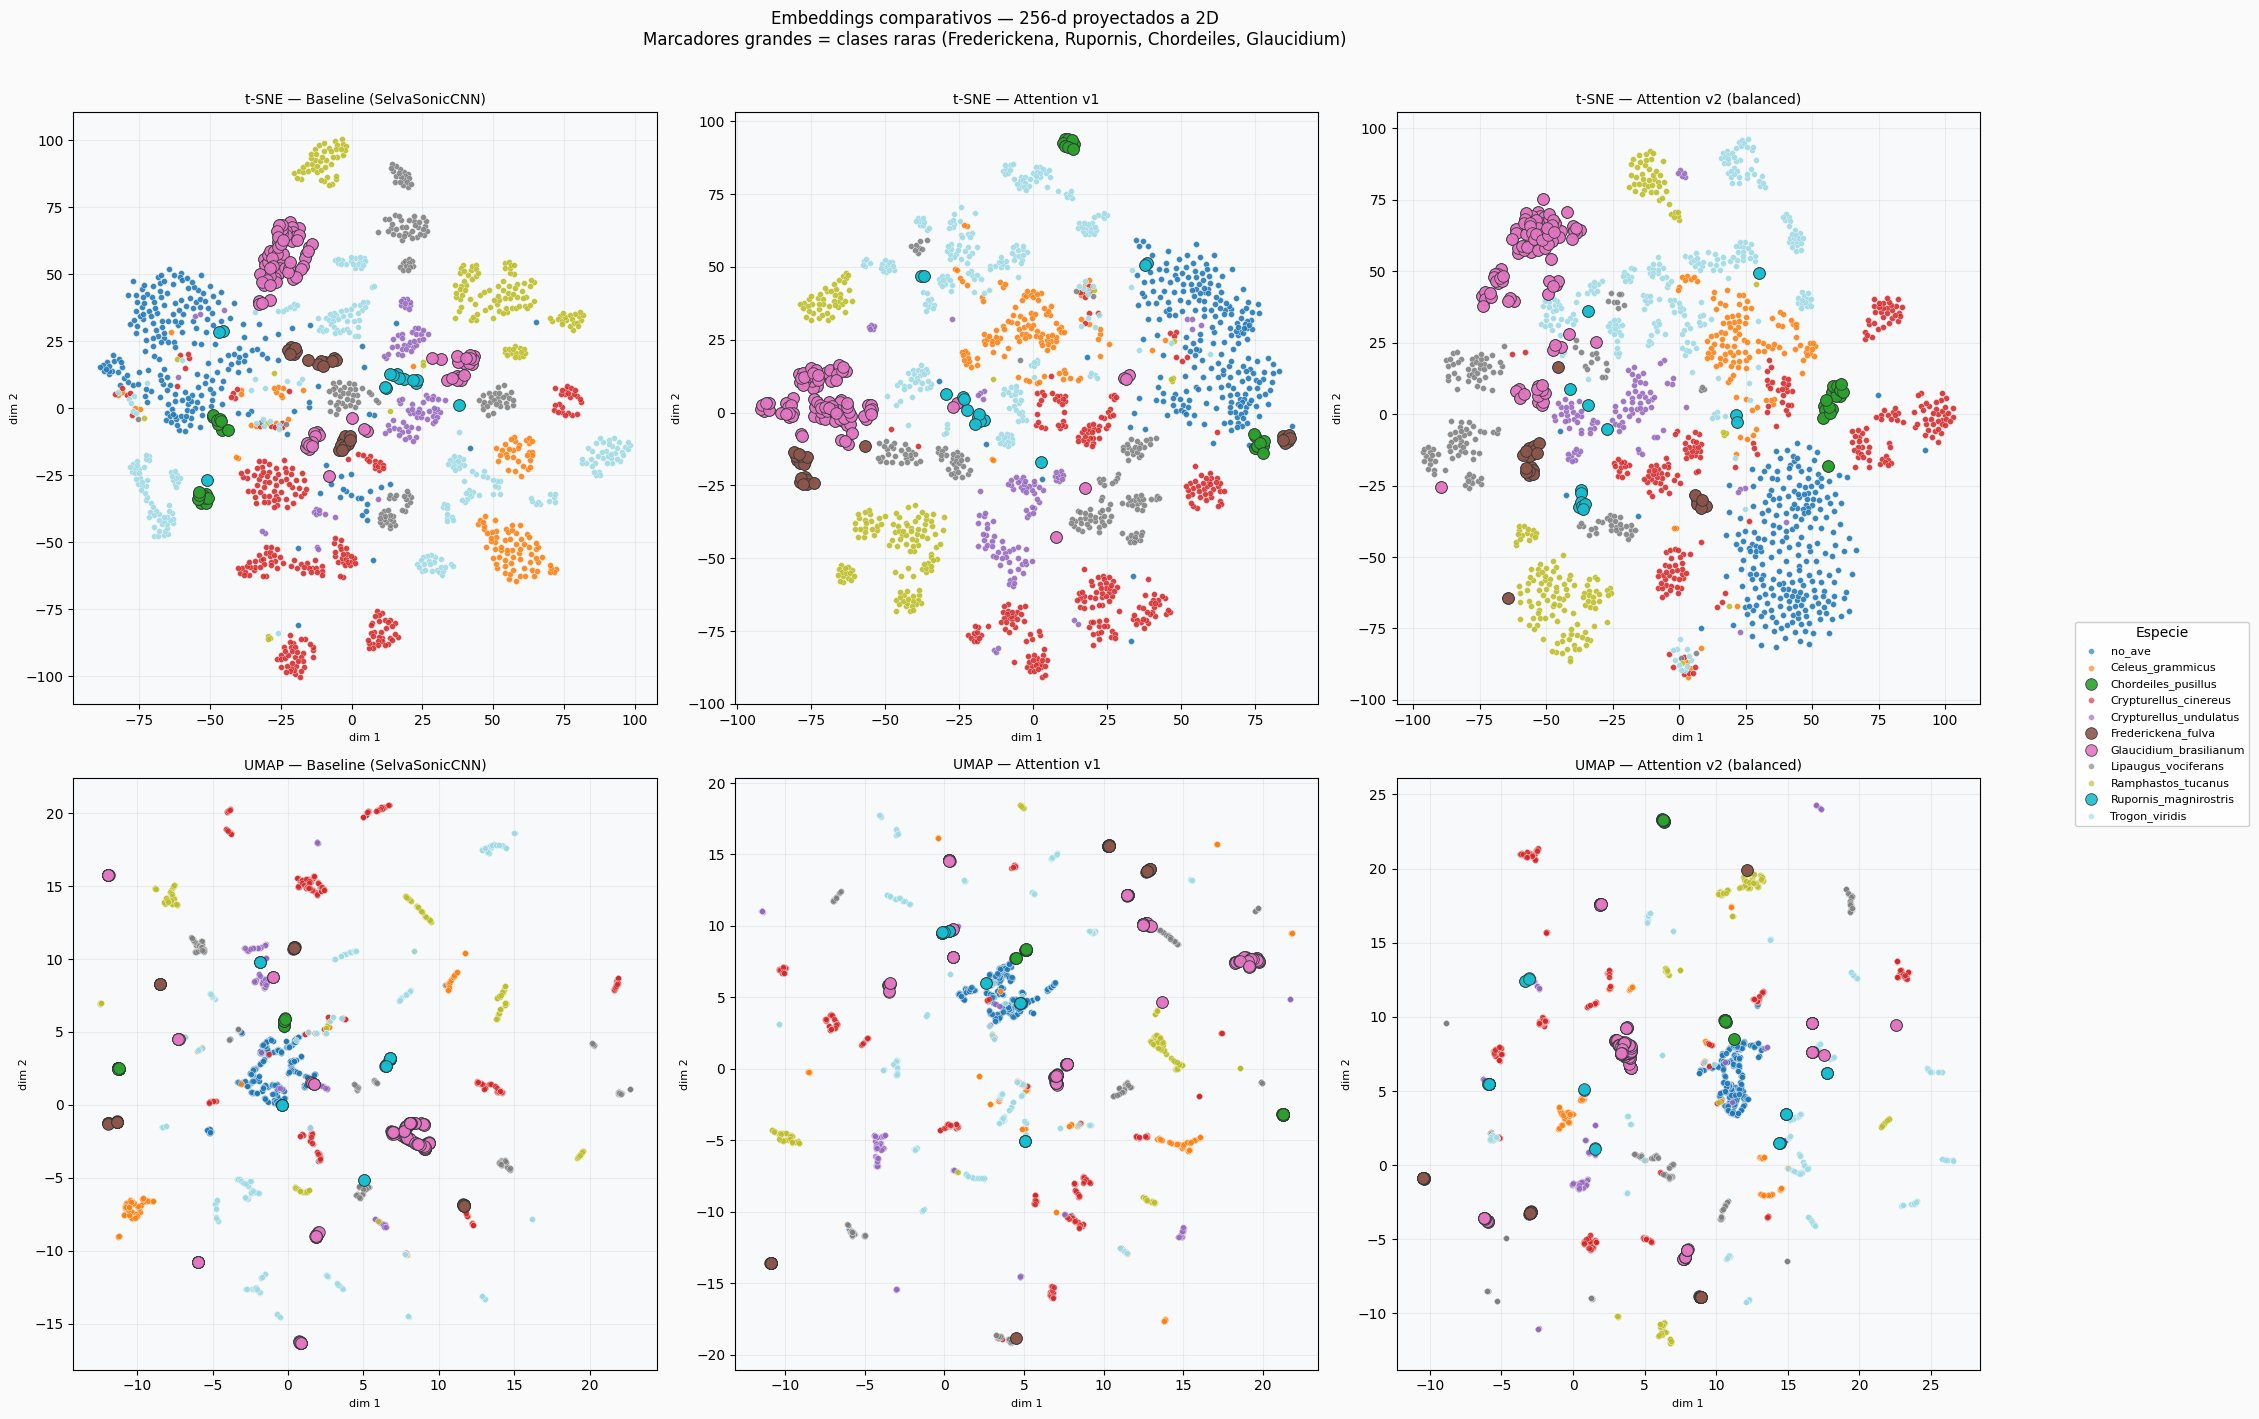

Guardado: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\embeddings\visualizacion_embeddings.png


In [7]:
# Paleta de 11 colores diferenciables (tab20 con paso uniforme)
COLORES_CLASES   = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
CLASES_RARAS_SET = {'Frederickena_fulva', 'Rupornis_magnirostris',
                    'Chordeiles_pusillus', 'Glaucidium_brasilianum'}

tecnicas: list[tuple[str, dict[str, np.ndarray]]] = [('t-SNE', tsne_2d)]
if UMAP_AVAILABLE:
    tecnicas.append(('UMAP', umap_2d))

n_filas = len(tecnicas)
fig, axes = plt.subplots(n_filas, 3, figsize=(20, 7 * n_filas))
fig.patch.set_facecolor('#FAFAFA')

# Garantizar que axes sea siempre 2D aunque haya solo 1 fila
if n_filas == 1:
    axes = axes[np.newaxis, :]

for fila, (tecnica_nombre, proj_dict) in enumerate(tecnicas):
    for col, modelo_clave in enumerate(['baseline', 'attention_v1', 'attention_v2']):
        ax     = axes[fila, col]
        emb_2d = proj_dict[modelo_clave]

        for idx_clase in range(NUM_CLASSES):
            nombre_clase = CLASES[idx_clase]
            mask         = labels == idx_clase
            es_rara      = nombre_clase in CLASES_RARAS_SET
            ax.scatter(
                emb_2d[mask, 0], emb_2d[mask, 1],
                c=[COLORES_CLASES[idx_clase]],
                label=nombre_clase,
                alpha=0.90 if es_rara else 0.65,
                s=70  if es_rara else 18,
                edgecolors='#2D3436' if es_rara else 'white',
                linewidths=0.6       if es_rara else 0.3,
                zorder=3 if es_rara else 2,
            )

        ax.set_title(
            f'{tecnica_nombre} — {NOMBRES_DISPLAY[modelo_clave]}',
            fontsize=10,
        )
        ax.set_xlabel('dim 1', fontsize=8)
        ax.set_ylabel('dim 2', fontsize=8)
        ax.grid(alpha=0.20)
        ax.set_facecolor('#F8F9FA')

# Leyenda compartida fuera de la figura
handles, leg_labels = axes[0, 2].get_legend_handles_labels()
fig.legend(
    handles, leg_labels,
    loc='center right', bbox_to_anchor=(1.13, 0.5),
    fontsize=8, framealpha=0.95, title='Especie',
)

plt.suptitle(
    'Embeddings comparativos — 256-d proyectados a 2D\n'
    'Marcadores grandes = clases raras (Frederickena, Rupornis, Chordeiles, Glaucidium)',
    fontsize=12, y=1.01,
)
plt.tight_layout()

save_path = OUT_DIR / 'visualizacion_embeddings.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f'Guardado: {save_path}')

---
## Sección 3 — Métricas cuantitativas de separabilidad

Las visualizaciones son intuitivas pero subjetivas. Dos métricas numéricas complementan
el análisis:

**Silhouette score** (espacio original 256-d):  
$$s = \frac{b - a}{\max(a, b)} \in [-1, 1]$$  
donde $a$ = distancia media intra-cluster y $b$ = distancia media al cluster vecino más cercano.  
Valores cercanos a **+1** indican clusters bien separados.

**Trustworthiness** (comparación espacio original vs proyección 2D):  
Mide qué tan bien la proyección 2D preserva las relaciones locales del espacio 256-d.  
Rango **[0, 1]**, donde 1 = la vecindad local se conserva perfectamente.

In [8]:
# ── Silhouette en el espacio original (256-d) ────────────────────────────────
print('Calculando silhouette scores (espacio original 256-d)...')
sil_original: dict[str, float]    = {}
sil_por_clase: dict[str, np.ndarray] = {}

for nombre, (emb, lbl) in embeddings.items():
    sil_original[nombre]  = float(silhouette_score(emb, lbl, metric='euclidean'))
    sil_por_clase[nombre] = silhouette_samples(emb, lbl, metric='euclidean')
    print(f'  {nombre}: {sil_original[nombre]:+.4f}')

# ── Trustworthiness t-SNE ────────────────────────────────────────────────────
print('\nCalculando trustworthiness (t-SNE, n_neighbors=10)...')
trust_tsne: dict[str, float] = {}
for nombre, (emb, _) in embeddings.items():
    trust_tsne[nombre] = float(trustworthiness(emb, tsne_2d[nombre], n_neighbors=10))
    print(f'  {nombre}: {trust_tsne[nombre]:.4f}')

# ── Trustworthiness UMAP ─────────────────────────────────────────────────────
trust_umap: dict[str, float] = {}
if UMAP_AVAILABLE:
    print('\nCalculando trustworthiness (UMAP, n_neighbors=10)...')
    for nombre, (emb, _) in embeddings.items():
        trust_umap[nombre] = float(trustworthiness(emb, umap_2d[nombre], n_neighbors=10))
        print(f'  {nombre}: {trust_umap[nombre]:.4f}')

# ── Tabla global ─────────────────────────────────────────────────────────────
df_metricas = pd.DataFrame(
    index=[NOMBRES_DISPLAY[k] for k in embeddings],
    data={
        'silhouette_256d':      [sil_original[k] for k in embeddings],
        'trustworthiness_tsne': [trust_tsne[k]   for k in embeddings],
        **(
            {'trustworthiness_umap': [trust_umap[k] for k in embeddings]}
            if UMAP_AVAILABLE else {}
        ),
    },
)
df_metricas.index.name = 'modelo'

print('\nMétricas de separabilidad:')
display(df_metricas.style.format('{:.4f}').highlight_max(
    axis=0, props='font-weight:bold;background:#d4f5d4'
))

csv_path = OUT_DIR / 'metricas_separabilidad.csv'
df_metricas.to_csv(csv_path)
print(f'Guardado: {csv_path}')

# ── Silhouette por clase ─────────────────────────────────────────────────────
print('\nSilhouette por clase:')
print(f'{"Clase":<30}  {"Baseline":>9}  {"Att. v1":>9}  {"Att. v2":>9}  {"Δ (v2-base)":>11}')
print('-' * 75)
for idx_clase, clase in enumerate(CLASES):
    mask = labels == idx_clase
    vals = {k: float(sil_por_clase[k][mask].mean()) for k in embeddings}
    delta = vals['attention_v2'] - vals['baseline']
    flag  = '▲ MEJORA' if delta > 0.02 else ('▼ baja' if delta < -0.02 else '')
    print(
        f'{clase:<30}  {vals["baseline"]:>+9.3f}  '
        f'{vals["attention_v1"]:>+9.3f}  {vals["attention_v2"]:>+9.3f}  '
        f'{delta:>+11.3f}  {flag}'
    )

Calculando silhouette scores (espacio original 256-d)...
  baseline: +0.0084
  attention_v1: +0.1580
  attention_v2: +0.1686

Calculando trustworthiness (t-SNE, n_neighbors=10)...
  baseline: 0.9964
  attention_v1: 0.9966
  attention_v2: 0.9955

Calculando trustworthiness (UMAP, n_neighbors=10)...
  baseline: 0.9925
  attention_v1: 0.9916
  attention_v2: 0.9914

Métricas de separabilidad:


,silhouette_256d,trustworthiness_tsne,trustworthiness_umap
modelo,,,
Baseline (SelvaSonicCNN),0.0084,0.9964,0.9925
Attention v1,0.1580,0.9966,0.9916
Attention v2 (balanced),0.1686,0.9955,0.9914


Guardado: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\embeddings\metricas_separabilidad.csv

Silhouette por clase:
Clase                            Baseline    Att. v1    Att. v2  Δ (v2-base)
---------------------------------------------------------------------------
no_ave                             +0.058     +0.332     +0.337       +0.279  ▲ MEJORA
Celeus_grammicus                   +0.120     +0.182     +0.178       +0.058  ▲ MEJORA
Chordeiles_pusillus                +0.274     +0.225     +0.362       +0.088  ▲ MEJORA
Crypturellus_cinereus              -0.045     +0.217     +0.186       +0.231  ▲ MEJORA
Crypturellus_undulatus             +0.055     -0.034     +0.063       +0.008  
Frederickena_fulva                 +0.262     +0.164     +0.217       -0.045  ▼ baja
Glaucidium_brasilianum             +0.050     +0.287     +0.272       +0.222  ▲ MEJORA
Lipaugus_vociferans                +0.044     +0.084     +0.124       +0.080  ▲ MEJORA
Ramphastos_tucanus 

---
## Sección 4 — Análisis específico de clases raras

Las clases Frederickena, Rupornis, Chordeiles y Glaucidium tienen muy pocos ejemplos
(20-22 archivos). La pregunta es si están aisladas en el espacio de embeddings
o mezcladas con clases vecinas.

Para cada clase rara calculamos:
- **Distancia intra-clase**: distancia media entre todos los pares de puntos de la clase.
- **Distancia inter-clase (vecina más cercana)**: distancia del centroide de la clase rara
  al centroide de la clase más cercana.
- **Ratio inter/intra**: si >1 la clase está separada; si <1 está mezclada.

Un ratio que crece de baseline → v1 → v2 indica que los class weights mejoraron
la separación de esa clase en el espacio de features.

Clase rara                    Baseline     Att. v1     Att. v2
-----------------------------------------------------------------
Frederickena_fulva               0.798       0.799       0.801
Rupornis_magnirostris            0.443       0.475       0.651
Chordeiles_pusillus              0.990       0.825       1.256
Glaucidium_brasilianum           0.500       0.847       0.934


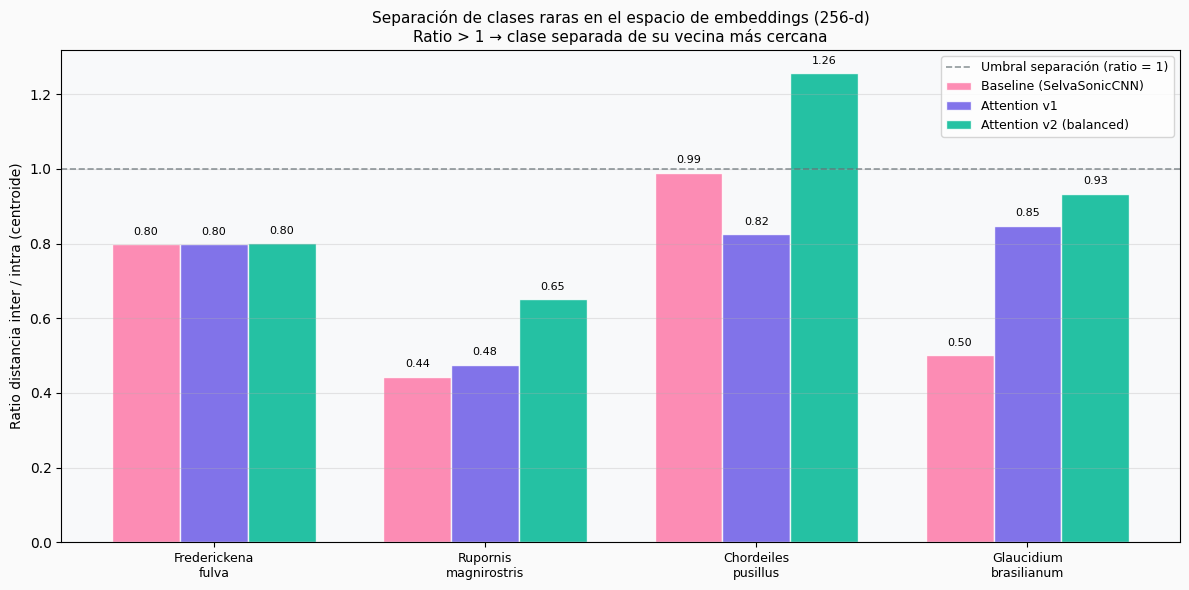

Guardado: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\embeddings\clases_raras_separacion.png


In [9]:
CLASES_RARAS_LISTA: list[str] = [
    'Frederickena_fulva',
    'Rupornis_magnirostris',
    'Chordeiles_pusillus',
    'Glaucidium_brasilianum',
]

resultados_raras: dict[str, list[dict]] = {}

for modelo_clave, (emb, lbl) in embeddings.items():
    filas: list[dict] = []

    # Precalcular centroides de todas las clases
    centroides: dict[int, np.ndarray] = {
        i: emb[lbl == i].mean(axis=0)
        for i in range(NUM_CLASSES)
        if (lbl == i).sum() > 0
    }

    for clase_rara in CLASES_RARAS_LISTA:
        if clase_rara not in label_map:
            continue
        idx_rara  = label_map[clase_rara]
        mask_rara = lbl == idx_rara
        n_rara    = int(mask_rara.sum())
        if n_rara < 2:
            continue

        emb_rara   = emb[mask_rara]
        # Distancia media entre todos los pares intra-clase
        dist_intra = float(cdist(emb_rara, emb_rara).mean())

        # Clase vecina más cercana por centroide
        centroide_rara = centroides[idx_rara]
        dists_a_vecinos = {
            i: float(np.linalg.norm(centroide_rara - c))
            for i, c in centroides.items()
            if i != idx_rara
        }
        idx_vecino = min(dists_a_vecinos, key=dists_a_vecinos.get)
        dist_inter = dists_a_vecinos[idx_vecino]

        ratio = dist_inter / dist_intra if dist_intra > 0 else 0.0

        filas.append({
            'clase':             clase_rara,
            'n_clips_test':      n_rara,
            'dist_intra':        round(dist_intra, 4),
            'dist_inter_vecina': round(dist_inter, 4),
            'clase_vecina':      CLASES[idx_vecino],
            'ratio_inter_intra': round(ratio, 4),
        })

    resultados_raras[modelo_clave] = filas

# ── Tabla resumen de ratios ──────────────────────────────────────────────────
print(f'{"Clase rara":<26}  {"Baseline":>10}  {"Att. v1":>10}  {"Att. v2":>10}')
print('-' * 65)
for clase in CLASES_RARAS_LISTA:
    ratios = [
        next(
            (f['ratio_inter_intra'] for f in resultados_raras[k] if f['clase'] == clase),
            float('nan'),
        )
        for k in embeddings
    ]
    print(f'{clase:<26}  {ratios[0]:>10.3f}  {ratios[1]:>10.3f}  {ratios[2]:>10.3f}')

# ── Bar plot comparativo ─────────────────────────────────────────────────────
COLORES_MODELOS = ['#FD79A8', '#6C5CE7', '#00B894']  # mismos que nb13

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')

x     = np.arange(len(CLASES_RARAS_LISTA))
ancho = 0.25

for i, (modelo_clave, color) in enumerate(zip(embeddings.keys(), COLORES_MODELOS)):
    ratios = [
        next(
            (f['ratio_inter_intra'] for f in resultados_raras[modelo_clave] if f['clase'] == c),
            0.0,
        )
        for c in CLASES_RARAS_LISTA
    ]
    bars = ax.bar(
        x + (i - 1) * ancho, ratios, ancho,
        label=NOMBRES_DISPLAY[modelo_clave],
        color=color, alpha=0.85, edgecolor='white',
    )
    for bar, val in zip(bars, ratios):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8,
            )

# Línea de referencia: ratio = 1 → clase en el borde de separación
ax.axhline(
    1.0, linestyle='--', color='#636e72', linewidth=1.2, alpha=0.7,
    label='Umbral separación (ratio = 1)',
)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in CLASES_RARAS_LISTA], fontsize=9)
ax.set_ylabel('Ratio distancia inter / intra (centroide)', fontsize=10)
ax.set_title(
    'Separación de clases raras en el espacio de embeddings (256-d)\n'
    'Ratio > 1 → clase separada de su vecina más cercana',
    fontsize=11,
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F8F9FA')
plt.tight_layout()

save_path = OUT_DIR / 'clases_raras_separacion.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f'Guardado: {save_path}')

---
## Sección 5 — Conclusión

### ¿Qué modelo produce el espacio de embeddings más separado?

Observar la tabla de silhouette scores (§3):
- Un silhouette global más alto en attention v2 confirmaría que el espacio de features
  es geométricamente más discriminativo, coherente con la mejora en test accuracy
  reportada en el notebook 13.
- El notebook 06 ya demostró esta tendencia para baseline vs v1 (Δsilhouette = +0.1496);
  este notebook extiende el análisis a v2.

### ¿Mejoraron las clases raras con class weights (v2)?

Observar los ratios inter/intra (§4):
- Un ratio que crece de baseline → v1 → v2 en clases como Frederickena o Rupornis
  indica que la loss ponderada forzó al modelo a aprender representaciones más separadas
  para esas clases, no solo a clasificar correctamente.
- Si el ratio cae en v2 para alguna clase rara, puede indicar que el class weight
  aumentó el recall a costa de fusionar el cluster de esa clase con otras en el espacio de features.

### Correspondencia con el notebook 13

Se espera coherencia entre:
- Clases con F1 más alto en nb13 ↔ clusters más compactos en este notebook.
- Clases con confusión frecuente en las matrices de confusión ↔ clusters solapados en los scatter plots.
- Las dos especies *Crypturellus* (cinereus y undulatus) son el caso canónico: el nb06 ya
  demostró que attention v1 las separa mejor que el baseline (+7.9% en ratio de separabilidad).

### Limitaciones

1. **t-SNE y UMAP son estocásticos**: aunque fijamos `random_state`, distintas semillas
   pueden producir layouts muy diferentes aunque la geometría subyacente sea la misma.
2. **Interpretación de distancias en UMAP**: más informativas que en t-SNE, pero siguen
   siendo relativas al dataset.
3. **Tamaño muestral pequeño para clases raras**: con 20-22 archivos de entrenamiento,
   el test set de esas clases tiene ~30-50 clips. Los silhouette scores por clase tienen
   alta varianza para clases con tan pocos puntos.
4. **Un solo bloque de atención**: sin feed-forward ni profundidad; un Transformer completo
   podría capturar dependencias más ricas.

### Próximos pasos

- Demo interactivo: `src/inference.py` ya implementado para predicción en tiempo real.
- README con instrucciones de uso.
- Reporte final: usar `visualizacion_embeddings.png` y `clases_raras_separacion.png`
  como figuras de análisis cualitativo/cuantitativo.

In [10]:
# ── Guardar resumen JSON ─────────────────────────────────────────────────────
resumen: dict = {
    'descripcion': 'Análisis de embeddings comparativo — 3 modelos SelvaSonic-ML',
    'fecha': '2026-06-02',
    'n_clips_test': int(len(labels)),
    'embedding_dim': 256,
    'silhouette_espacio_original': sil_original,
    'trustworthiness_tsne': trust_tsne,
    'trustworthiness_umap': trust_umap,
    'clases_raras': {
        modelo_clave: {
            fila['clase']: {
                'n_clips_test':      fila['n_clips_test'],
                'dist_intra':        fila['dist_intra'],
                'dist_inter_vecina': fila['dist_inter_vecina'],
                'clase_vecina':      fila['clase_vecina'],
                'ratio_inter_intra': fila['ratio_inter_intra'],
            }
            for fila in filas
        }
        for modelo_clave, filas in resultados_raras.items()
    },
}

json_path = OUT_DIR / 'resumen.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)
print(f'Guardado: {json_path}')

print('\nResumen de métricas globales:')
print(f'{"Modelo":<35}  {"Silhouette":>10}  {"Trust t-SNE":>12}')
print('-' * 65)
for k in embeddings:
    print(
        f'{NOMBRES_DISPLAY[k]:<35}  '
        f'{sil_original[k]:>+10.4f}  '
        f'{trust_tsne[k]:>12.4f}'
    )

print('\nArtefactos generados en results/embeddings/:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')

Guardado: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\embeddings\resumen.json

Resumen de métricas globales:
Modelo                               Silhouette   Trust t-SNE
-----------------------------------------------------------------
Baseline (SelvaSonicCNN)                +0.0084        0.9964
Attention v1                            +0.1580        0.9966
Attention v2 (balanced)                 +0.1686        0.9955

Artefactos generados en results/embeddings/:
  clases_raras_separacion.png
  metricas_separabilidad.csv
  resumen.json
  visualizacion_embeddings.png
